In [ ]:
# Student Performance Analysis

In [ ]:
## Problem Statement
The objective of this project is to analyze student performance data and identify the key factors that influence academic scores.

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [35]:
import pandas as pd

df = pd.read_csv("StudentsPerformance.csv")


df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [38]:
# Check null values
df.isnull().sum()

df.columns = df.columns.str.replace(" ", "_")

df['average_score'] = (df['math_score'] + df['reading_score'] + df['writing_score']) / 3

df.head()

,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


In [19]:
df.columns = df.columns.str.replace(" ", "_")
df.columns

Index(['gender', 'race/ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score', 'average_score'],
      dtype='str')

## Gender Selection

In [21]:
df.groupby('gender')['average_score'].mean()

gender
female    69.569498
male      65.837483
Name: average_score, dtype: float64

## Improve insight:

Female students have a slightly higher average score compared to male students, indicating more consistent performance.

## Test Preparation

In [8]:
df.groupby('test_preparation_course')['average_score'].mean()

test_preparation_course
completed    72.669460
none         65.038941
Name: average_score, dtype: float64

## Key Insight:

Students who completed the test preparation course scored significantly higher (around X) compared to those who did not (around Y), showing a strong positive impact of preparation.

In [9]:
df.groupby('lunch')['average_score'].mean()

lunch
free/reduced    62.199061
standard        70.837209
Name: average_score, dtype: float64

## Insight:

Students with standard lunch scored higher than those with free/reduced lunch, indicating that economic background affects academic performance.

In [10]:
df.groupby('parental_level_of_education')['average_score'].mean().sort_values()

parental_level_of_education
high school           63.096939
some high school      65.108007
some college          68.476401
associate's degree    69.569069
bachelor's degree     71.923729
master's degree       73.598870
Name: average_score, dtype: float64

## Insight:

Students whose parents have higher education levels tend to achieve better academic performance.

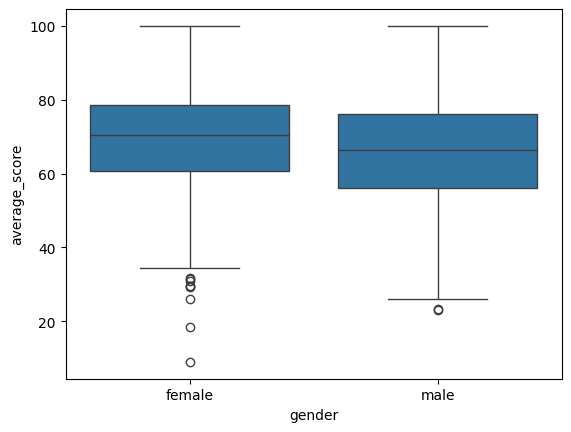

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='gender', y='average_score', data=df)
plt.show()

Female students have a slightly higher median average score than male students
Female scores are more consistent (tighter box)
Male scores show slightly more variation
Both groups have some low-score outliers

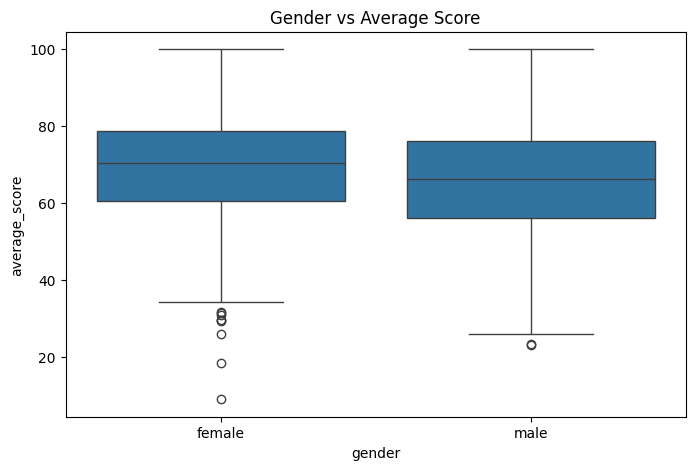

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(x='gender', y='average_score', data=df)
plt.title("Gender vs Average Score")
plt.show()

### Insight:
Female students show slightly higher median scores and more consistent performance compared to male students.

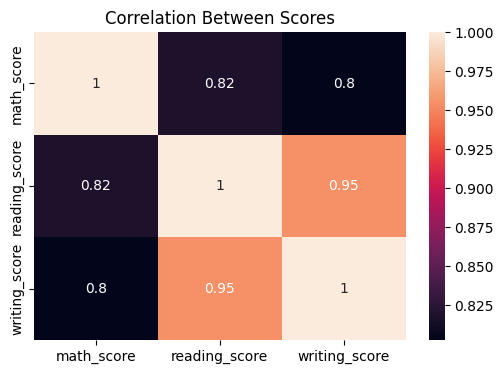

In [32]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['math_score','reading_score','writing_score']].corr(), annot=True)
plt.title("Correlation Between Scores")
plt.show()

### Insight:
Reading and writing scores show a strong positive correlation, indicating that both skills are closely related, while math follows a slightly different trend.

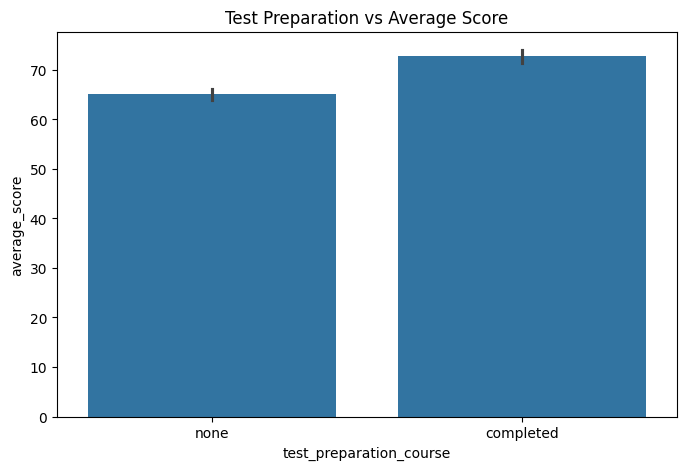

In [28]:
plt.figure(figsize=(8,5))
sns.barplot(x='test_preparation_course', y='average_score', data=df)
plt.title("Test Preparation vs Average Score")
plt.show()

In [ ]:
### Insight:
Students who completed the test preparation course scored significantly higher, showing that preparation strongly improves performance.

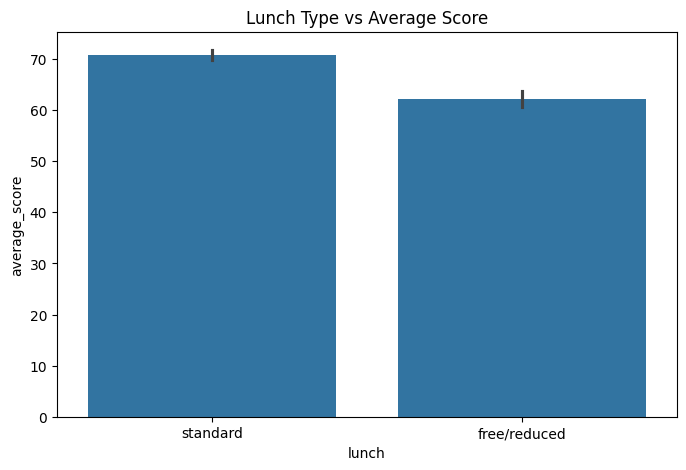

In [29]:
plt.figure(figsize=(8,5))
sns.barplot(x='lunch', y='average_score', data=df)
plt.title("Lunch Type vs Average Score")
plt.show()

### Insight:
Students who completed the test preparation course scored significantly higher, showing that preparation strongly improves performance.

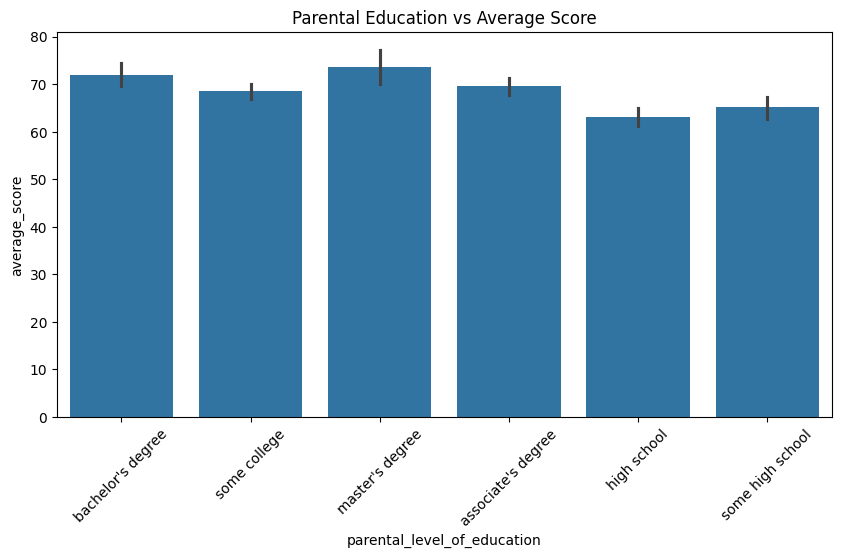

In [30]:
plt.figure(figsize=(10,5))
sns.barplot(x='parental_level_of_education', y='average_score', data=df)
plt.xticks(rotation=45)
plt.title("Parental Education vs Average Score")
plt.show()

### Insight:
Higher parental education levels are associated with better student performance.

## Conclusion

Student performance is influenced by multiple factors. Test preparation has the strongest impact on improving scores. Economic background, represented by lunch type, also plays a significant role. Parental education positively affects student outcomes. Female students tend to perform slightly better and more consistently. A strong correlation between reading and writing suggests shared skill development.